In [8]:
import numpy as np
import matplotlib.pyplot as plt


# EX1-linearni

['t', 'f']
[ 1.04856908  1.01721264 -6.26245396 -8.12486839]
       3         2
1.049 x + 1.017 x - 6.262 x - 8.125
(-3.0, 3.0)
[-3.         -2.87755102 -2.75510204 -2.63265306 -2.51020408 -2.3877551
 -2.26530612 -2.14285714 -2.02040816 -1.89795918 -1.7755102  -1.65306122
 -1.53061224 -1.40816327 -1.28571429 -1.16326531 -1.04081633 -0.91836735
 -0.79591837 -0.67346939 -0.55102041 -0.42857143 -0.30612245 -0.18367347
 -0.06122449  0.06122449  0.18367347  0.30612245  0.42857143  0.55102041
  0.67346939  0.79591837  0.91836735  1.04081633  1.16326531  1.28571429
  1.40816327  1.53061224  1.65306122  1.7755102   1.89795918  2.02040816
  2.14285714  2.26530612  2.3877551   2.51020408  2.63265306  2.75510204
  2.87755102  3.        ]


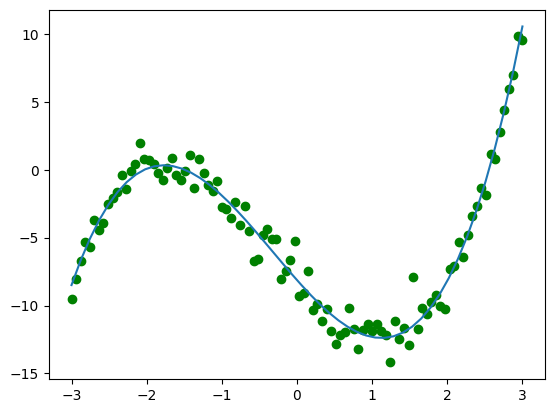

In [43]:
d = np.load('drive/MyDrive/colab/ExSet4_Q1.npz')
#print(dict(d))
print(list(d.keys()))
t,f = d['t'], d['f']

# nejdriv fitneme koeficienty
z = np.polyfit(t, f, 3)
print(z) # [ 1.04856908  1.01721264 -6.26245396 -8.12486839]
func = np.poly1d(z)
print(func) # vytvorime polynom 1D protoze staci 1.049 x + 1.017 x - 6.262 x - 8.125
print((t[0], t[-1])) # pripravime prvni a posledni a udelame linearne separovany space 50 prvku
t_new = np.linspace(t[0], t[-1], 50)
print(t_new)
# dosadime do polynomu
f_new = func(t_new)

plt.scatter(t,f, c='green')
# vyplotujeme
plt.plot(t_new ,f_new)

# EX2 neliearni

['t', 'f']
       3         2
1.243 x - 3.667 x + 3.162 x - 0.008458
(0.0, 2.0)


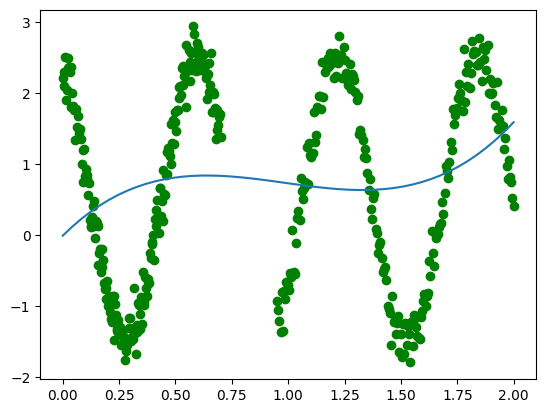

In [44]:
d = np.load('drive/MyDrive/colab/ExSet4_Q2.npz')
#print(dict(d))
print(list(d.keys()))
t,f = d['t'], d['f']

# nejdriv fitneme koeficienty
z = np.polyfit(t, f, 3)
# print(z) # [ 1.04856908  1.01721264 -6.26245396 -8.12486839]
func = np.poly1d(z)
print(func) # vytvorime polynom 1D protoze staci 1.049 x + 1.017 x - 6.262 x - 8.125
print((t[0], t[-1])) # pripravime prvni a posledni a udelame linearne separovany space 50 prvku
t_new = np.linspace(t[0], t[-1], 50)
# print(t_new)
# # dosadime do polynomu
f_new = func(t_new)

plt.scatter(t,f, c='green')
# vyplotujeme
plt.plot(t_new ,f_new)

# EX3 nelinearni lepe

['t', 'f']
chi2 = 469.7133400508783
Optimization terminated successfully.
         Current function value: 15.396104
         Iterations: 133
         Function evaluations: 223


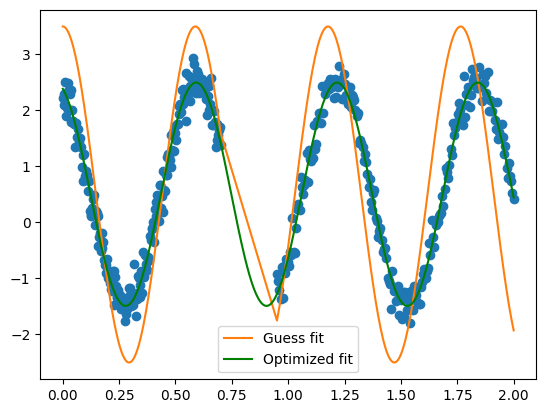

In [47]:
import scipy.optimize as opt
from scipy.optimize import leastsq
d = np.load('drive/MyDrive/colab/ExSet4_Q2.npz')
print(list(d.keys()))
t,f = d['t'], d['f']
tfit = np.linspace(min(t),max(t),len(t))

def chi2(x,t,y):

    return np.sum((y - model(x,t))**2)

def model(x,t):
  return x[0]*np.sin(x[1]*t+x[2]) + x[3]

x0 = np.array([3.0,2*np.pi*1.7,np.pi/2,0.5])
print("chi2 =", chi2(x0,t,f))
x0_fit = opt.fmin(chi2,x0,(t,f))

plt.plot(t,f, 'o')
plt.plot(t,model(x0,t), label = 'Guess fit')
plt.plot(tfit,model(x0_fit,tfit),'g-', label = 'Optimized fit')
plt.legend()

plt.show()

chi2 = 187.8261277880105
chi2 = 15.396103206909324
p[0] = 1.993985+-0.007235
p[1] = 10.056538+-0.005617
p[2] = 1.906759+-0.006199
p[3] = 0.504665+-0.005085


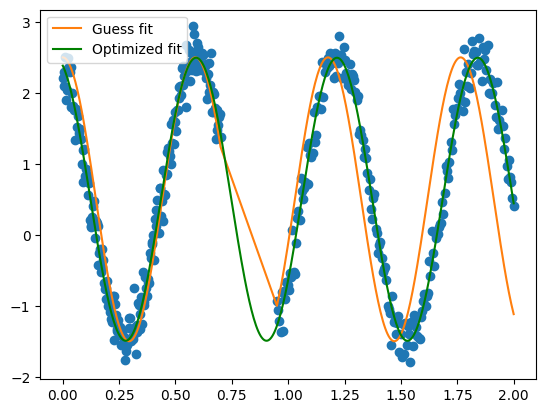

[0.         0.00351759 0.00703518 0.01055276 0.01407035 0.01758794
 0.02110553 0.02462312 0.0281407  0.03165829 0.03517588 0.03869347
 0.04221106 0.04572864 0.04924623 0.05276382 0.05628141 0.05979899
 0.06331658 0.06683417 0.07035176 0.07386935 0.07738693 0.08090452
 0.08442211 0.0879397  0.09145729 0.09497487 0.09849246 0.10201005
 0.10552764 0.10904523 0.11256281 0.1160804  0.11959799 0.12311558
 0.12663317 0.13015075 0.13366834 0.13718593 0.14070352 0.14422111
 0.14773869 0.15125628 0.15477387 0.15829146 0.16180905 0.16532663
 0.16884422 0.17236181 0.1758794  0.17939698 0.18291457 0.18643216
 0.18994975 0.19346734 0.19698492 0.20050251 0.2040201  0.20753769
 0.21105528 0.21457286 0.21809045 0.22160804 0.22512563 0.22864322
 0.2321608  0.23567839 0.23919598 0.24271357 0.24623116 0.24974874
 0.25326633 0.25678392 0.26030151 0.2638191  0.26733668 0.27085427
 0.27437186 0.27788945 0.28140704 0.28492462 0.28844221 0.2919598
 0.29547739 0.29899497 0.30251256 0.30603015 0.30954774 0.31306

In [51]:
def residuals(p,f,x,y,s=1):
    return (y - f(p,x)) / s

x0 = np.array([2,2*np.pi*1.7,np.pi/2,0.504])
sigma = 0.1
print("chi2 =", chi2(x0,t,f))
r = residuals(x0,model,t,f)
result = opt.least_squares(residuals,x0,args=(model,t,f,sigma))
x0_fit = result.x
print("chi2 =", chi2(x0_fit,t,f))


H = np.dot(result.jac.T,result.jac) #estimate the hessian matrix
K_fit = np.linalg.pinv(H) #covariance matrix
e_fit = np.sqrt(np.diag(K_fit)) #stdevs

for i in range(x0_fit.size):
    print("p[{}] = {:3f}+-{:3f}".format(i,x0_fit[i],e_fit[i]))
# print("red chi2 =", np.sum(residuals(x0_fit,model,t,f)**2) / (x.size - len(x0_fit)))
plt.plot(t,f, 'o')
plt.plot(t,model(x0,t), label = 'Guess fit')
plt.plot(tfit,model(x0_fit,tfit),'g-', label = 'Optimized fit')
plt.legend()

plt.show()
print(t)
print(f)

## gaussian fit

['x', 'f']
-5.0
p[0] = 0.29965315094916606+-0.0017693343264778096
p[1] = 0.17346644903534122+-0.0014446554607184569
p[2] = 0.11039583326207368+-0.0011597972768094867


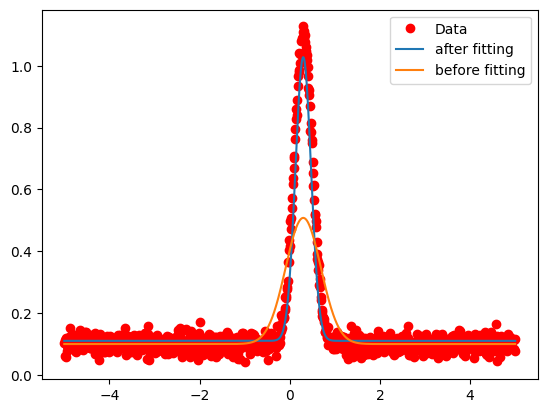

In [57]:
from scipy.optimize import curve_fit
d = np.load('drive/MyDrive/colab/ExSet4_Q3.npz')
print(list(d.keys()))
x,f = d['x'], d['f']

def gaussian(x, mu, sig, y):
    return 1./((2.*np.pi)*sig)*np.exp(-(x - mu)**2/(2*sig**2)) + y

print(min(x))


# Guess array
x0 = np.array([0.5,0.1,0.1])
# Curvefit, first is parameters, second covariance matrix
fit, covM = curve_fit(gaussian, x, f, p0=x0)
# Errors of parameters from covariance matrix
perr = np.sqrt(np.diag(covM))

# Printing parameters
for i in range(len(x0)):
    print(f"p[{i}] = {fit[i]}+-{perr[i]}")
x1 = np.linspace(min(x),max(x),100)
plt.plot(x,f, 'ro', label = 'Data')
plt.plot(x,gaussian(x, *fit), label='after fitting')
plt.plot(x,gaussian(x,0.3,0.39,0.1), label ='before fitting')
plt.legend()

# scikit - clustering

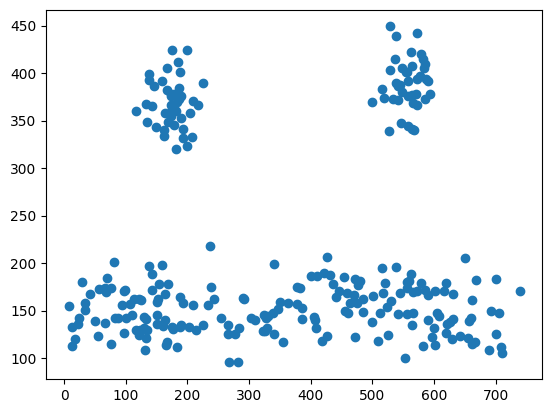

In [79]:
from sklearn.cluster import DBSCAN
data = np.genfromtxt('drive/MyDrive/colab/clusters.csv', delimiter=',', skip_header=1)

column_1 = data[:, 0]  # First column
column_2 = data[:, 1]  # Second column
plt.scatter(column_1, column_2)  # 'c' is used for color, 's' for marker size

https://drawdata.xyz/

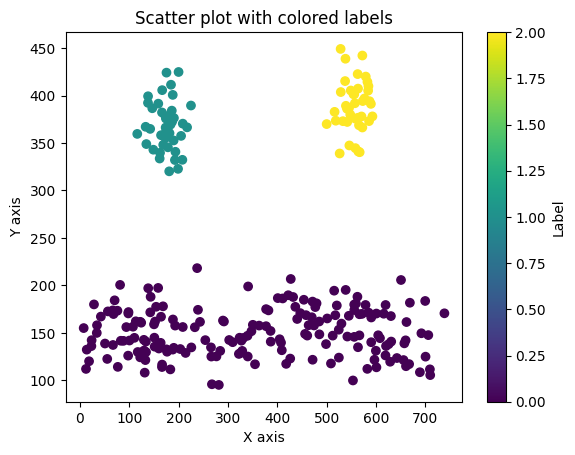

In [80]:


X = np.column_stack((column_1, column_2))

dbscan = DBSCAN(eps=50, min_samples=5)

clustering = dbscan.fit(X)
clustering.labels_

plt.scatter(column_1, column_2, c=clustering.labels_, cmap='viridis')  # 'c' is used for color

# Optional: Add a color bar to indicate what the colors represent
plt.colorbar(label='Label')

# Labeling the plot
plt.title("Scatter plot with colored labels")
plt.xlabel("X axis")
plt.ylabel("Y axis")

# Show plot
plt.show()

scikit - outliers

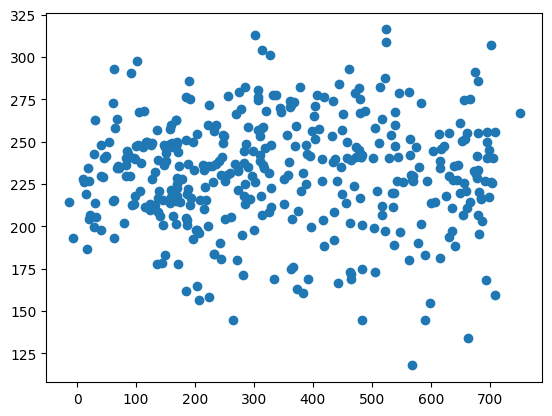

In [82]:
data = np.genfromtxt('drive/MyDrive/colab/outliers.csv', delimiter=',', skip_header=1)

column_1 = data[:, 0]  # First column
column_2 = data[:, 1]  # Second column

plt.scatter(column_1, column_2)  # 'c' is used for color, 's' for marker size

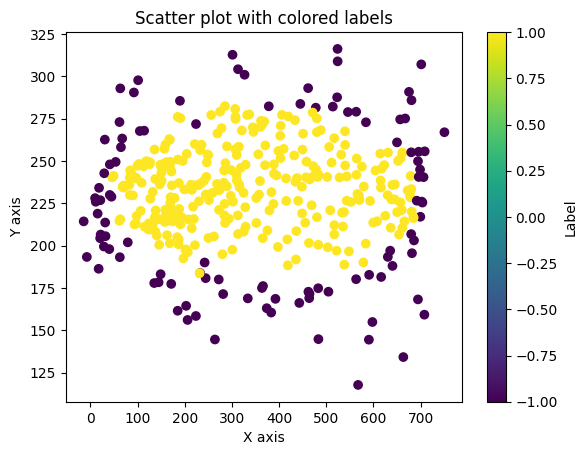

In [87]:
from sklearn.ensemble import IsolationForest


X = np.column_stack((column_1, column_2))
clf = IsolationForest(random_state=0).fit(X)
labels = clf.predict(X)

plt.scatter(column_1, column_2, c=labels)  # 'c' is used for color

# Optional: Add a color bar to indicate what the colors represent
plt.colorbar(label='Label')

# Labeling the plot
plt.title("Scatter plot with colored labels")
plt.xlabel("X axis")
plt.ylabel("Y axis")

# Show plot
plt.show()


# novelties

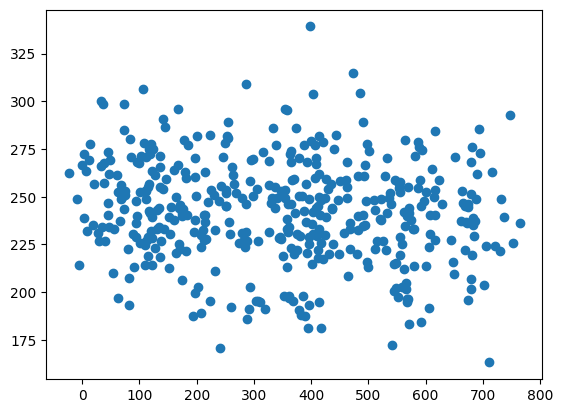

In [90]:
# data z měření - validní

data = np.genfromtxt('drive/MyDrive/colab/novelty_train.csv', delimiter=',', skip_header=1)

column_X1 = data[:, 0]  # First column
column_X2 = data[:, 1]  # Second column

plt.scatter(column_X1, column_X2)

# naučíme model na tom co známe

In [91]:
from sklearn.neighbors import LocalOutlierFactor

X = np.column_stack((column_X1, column_X2))
clf = LocalOutlierFactor(n_neighbors=3, novelty=True)

clf.fit(X)


LocalOutlierFactor(n_neighbors=3, novelty=True)

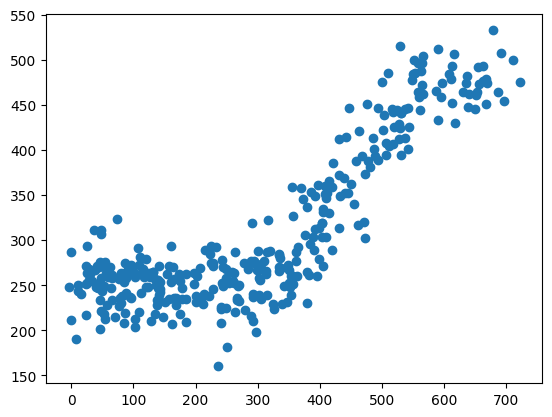

In [92]:
# data z měření - testovaci

data = np.genfromtxt('drive/MyDrive/colab/novelty_test.csv', delimiter=',', skip_header=1)

column_Y1 = data[:, 0]  # First column
column_Y2 = data[:, 1]  # Second column

plt.scatter(column_Y1, column_Y2)


# otestujeme model

Text(0, 0.5, 'Y axis')

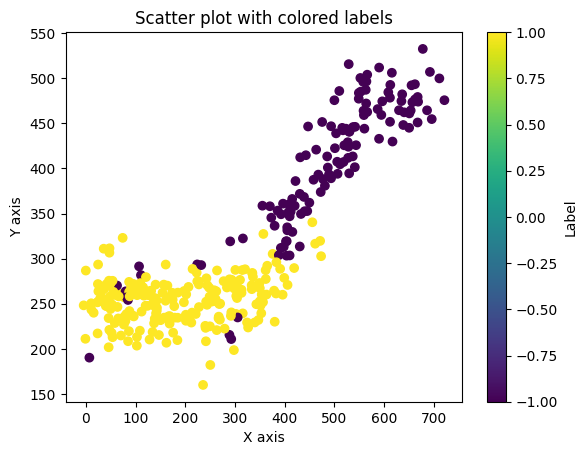

In [95]:
Y = np.column_stack((column_Y1, column_Y2))

labels = clf.predict(Y)
plt.scatter(column_Y1, column_Y2, c=labels)  # 'c' is used for color

# Optional: Add a color bar to indicate what the colors represent
plt.colorbar(label='Label')

# Labeling the plot
plt.title("Scatter plot with colored labels")
plt.xlabel("X axis")
plt.ylabel("Y axis")



# domáci úkol - odsazene nedavej

Approximated value of π: 0.7873


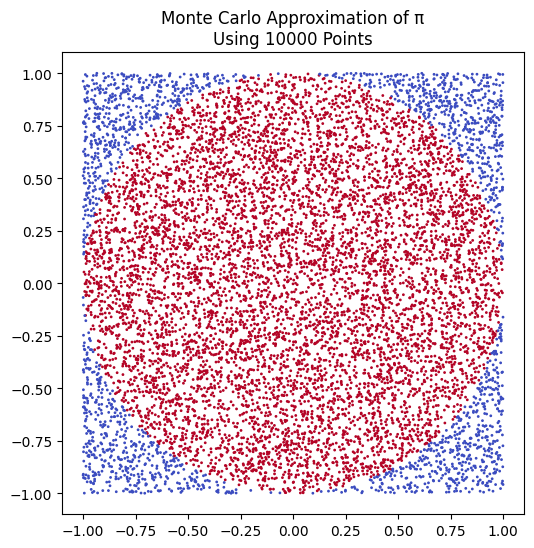

In [105]:
import numpy as np
import matplotlib.pyplot as plt

# Nastavme pocet pokusu - cim vice tim lepe
n_samples = 10000

# vytvorime 10000 nahodych x a 10000 nahodnych y
xs = np.random.uniform(-1, 1, n_samples)
ys = np.random.uniform(-1, 1, n_samples)

# spocitej eukl. vzdalenost jednotlivych bodu
 # distances = np.sqrt(xs**2 + ys**2)

# spocitej pocet bodu ktere padnou do jednotkove kruznice (polomer = 1) a to takto:
# napis funkci která vráti pole True, False, True, False.. podle toho jestli je dana vzdalenost <=1
# vysledek uloz do promenne: inside_circle
# spocitej kolik jich je True a vysledek uloz do promenne: n_inside_circle

 #inside_circle = distances <= 1
 #n_inside_circle = np.sum(inside_circle)

# Approximuj π jako pomer bodu uvnitr ku vsem bodum the circle to the total points
# Čtverec má stranu 2r
# A teda plochu 4r²
# kruh má πr²
# rozdíl je π a 4
# proto 4 přídáme do vypočtu
pi_approx = 4 * n_inside_circle / n_samples

# Output the result
print(f"Approximated value of π: {pi_approx}")

# Optional: Visualization
plt.figure(figsize=(6, 6))
plt.scatter(xs, ys, c=inside_circle, cmap='coolwarm', s=1)
plt.title(f"Monte Carlo Approximation of π\nUsing {n_samples} Points")
plt.gca().set_aspect('equal', 'box')
plt.show()